In [58]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, spearmanr
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import cross_val_score
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from urllib.request import urlretrieve
from scipy.stats import pearsonr

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [44]:
FILES = {
    'test.csv':              '1WWWGrnJxXpsgVSgys8aH5eBMIGH_X12b',
    'train.csv':             '1brpMi8-L4hT3ZsYB7w3mffk3aGPopQrT',
    'sample_submission.csv': '1djFrLa7sejtRY7z2kpn35vxImjDf8umz',
}

for filename, file_id in FILES.items():
    url = f'https://drive.google.com/uc?id={file_id}'
    print(f'Загружен {filename}...')
    urlretrieve(url, filename)

Загружен test.csv...
Загружен train.csv...
Загружен sample_submission.csv...


In [50]:
train      = pd.read_csv('train.csv').set_index('index')
test       = pd.read_csv('test.csv').set_index('index')
sample_sub = pd.read_csv('sample_submission.csv').set_index('index')

TARGETS  = ['IC50, mM', 'CC50, mM', 'SI']
features = [c for c in train.columns if c not in TARGETS]

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
print(f'Features:    {len(features)}')

Train shape: (751, 213)
Test shape:  (250, 210)
Features:    210


# Обзор данных

In [45]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 751 entries, 0 to 750
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.2 MB


In [46]:
train.head().T

index,0,1,2,3,4
"IC50, mM",102.414420,0.044333,4.437964,6.827881,2.003253
"CC50, mM",95.757483,8.401080,50.085589,682.788051,70.001455
SI,0.935000,189.500000,11.285714,100.000000,34.943894
MaxAbsEStateIndex,5.466584,11.492712,5.366084,13.317130,6.320833
MaxEStateIndex,5.466584,11.492712,5.366084,13.317130,6.320833
...,...,...,...,...,...
fr_thiazole,0.000000,0.000000,0.000000,0.000000,0.000000
fr_thiocyan,0.000000,0.000000,0.000000,0.000000,0.000000
fr_thiophene,0.000000,0.000000,0.000000,0.000000,0.000000
fr_unbrch_alkane,0.000000,0.000000,0.000000,0.000000,0.000000


In [47]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
"IC50, mM",751.0,204.544021,370.367937,0.003517,13.222351,44.069306,206.787402,4095.188563
"CC50, mM",751.0,577.426098,641.515163,0.700808,99.998894,376.580899,877.508784,4538.976189
SI,751.0,89.153313,788.882198,0.011489,1.500000,4.000000,17.372463,15620.600000
MaxAbsEStateIndex,751.0,10.860070,3.347314,2.321942,8.921032,12.197500,13.214245,15.933463
MaxEStateIndex,751.0,10.860070,3.347314,2.321942,8.921032,12.197500,13.214245,15.933463
...,...,...,...,...,...,...,...,...
fr_thiazole,751.0,0.054594,0.227337,0.000000,0.000000,0.000000,0.000000,1.000000
fr_thiocyan,751.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
fr_thiophene,751.0,0.069241,0.254033,0.000000,0.000000,0.000000,0.000000,1.000000
fr_unbrch_alkane,751.0,0.182423,1.227468,0.000000,0.000000,0.000000,0.000000,20.000000


## Пропуски

In [48]:
missing_train = train.isnull().sum().sort_values(ascending=False)
missing_test  = test.isnull().sum().sort_values(ascending=False)

print('Пропуски в train:')
print(missing_train[missing_train > 0])
print()
print('Пропуски в test:')
print(missing_test[missing_test > 0])

Пропуски в train:
MinAbsPartialCharge    2
MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MRLOW           2
BCUT2D_MRHI            2
BCUT2D_LOGPLOW         2
BCUT2D_LOGPHI          2
BCUT2D_CHGLO           2
BCUT2D_CHGHI           2
BCUT2D_MWLOW           2
dtype: int64

Пропуски в test:
MaxAbsPartialCharge    1
MinAbsPartialCharge    1
MinPartialCharge       1
MaxPartialCharge       1
BCUT2D_LOGPLOW         1
BCUT2D_LOGPHI          1
BCUT2D_CHGLO           1
BCUT2D_CHGHI           1
BCUT2D_MWLOW           1
BCUT2D_MWHI            1
BCUT2D_MRLOW           1
BCUT2D_MRHI            1
dtype: int64


Пропуски обнаружены только в 12 признаках группы PartialCharge и BCUT2D — по 2 объекта в train и 1 в test.
Пропуски имеют структурный характер: эти дескрипторы не рассчитываются для отдельных молекул.
Стратегия заполнения: медиана по train.

## Дубликаты по признакам

In [51]:
dup_mask      = train.duplicated(subset=features, keep=False)
dup_groups    = train[dup_mask].groupby(features)[TARGETS].agg(['mean', 'std', 'count'])
n_dup_objects = dup_mask.sum()

print(f'Объектов с одинаковыми признаками: {n_dup_objects}')
print(f'Из них групп: {dup_mask.sum() - train.duplicated(subset=features).sum()}')

Объектов с одинаковыми признаками: 181
Из них групп: 60


In [52]:
# Проверяем разброс таргетов внутри дублей
dup_targets = train[dup_mask].copy()
dup_targets['group'] = train[dup_mask].groupby(features).ngroup()

std_per_group = dup_targets.groupby('group')[TARGETS].std()
print('Средний std таргетов внутри групп дублей:')
print(std_per_group.mean())

Средний std таргетов внутри групп дублей:
IC50, mM    135.322191
CC50, mM    237.878620
SI          215.890128
dtype: float64


Обнаружены объекты с одинаковыми дескрипторами и различными значениями таргетов.
Это указывает на шум биологических измерений или повторные эксперименты.
Данное свойство создает естественный потолок качества модели.
Стратегия: не удалять дубликаты, использовать GroupKFold при валидации.

## Константные признаки

In [53]:
# Константные в train
constant_train = [c for c in features if train[c].nunique() <= 1]
print(f'Константных в train: {len(constant_train)}')
print(constant_train)

# Константные в объединении train+test
combined = pd.concat([train[features], test[features]], axis=0)
constant_combined = [c for c in features if combined[c].nunique() <= 1]
print(f'\nКонстантных в train+test: {len(constant_combined)}')

Константных в train: 18
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']

Константных в train+test: 18


# Анализ целевых переменных

## Связь SI с IC50 и CC50

In [55]:
si_computed = train['CC50, mM'] / train['IC50, mM']
diff = (si_computed - train['SI']).abs()
print(f'SI = CC50/IC50 точно для всех объектов: {(diff < 0.01).all()}')
print(f'Максимальное отклонение: {diff.max():.2e}')

SI = CC50/IC50 точно для всех объектов: True
Максимальное отклонение: 2.00e-11


SI = CC50 / IC50 абсолютно точно для всех 751 объектов.
SI не является независимой целевой переменной, он полностью определяется через IC50 и CC50.
Это означает, что SI можно не предсказывать отдельной моделью, а вычислять из предсказаний IC50 и CC50.

## Распределения таргетов

IC50, mM: skew=3.79  ->  log skew=-0.06
CC50, mM: skew=2.06  ->  log skew=-0.90
SI: skew=15.63  ->  log skew=1.54


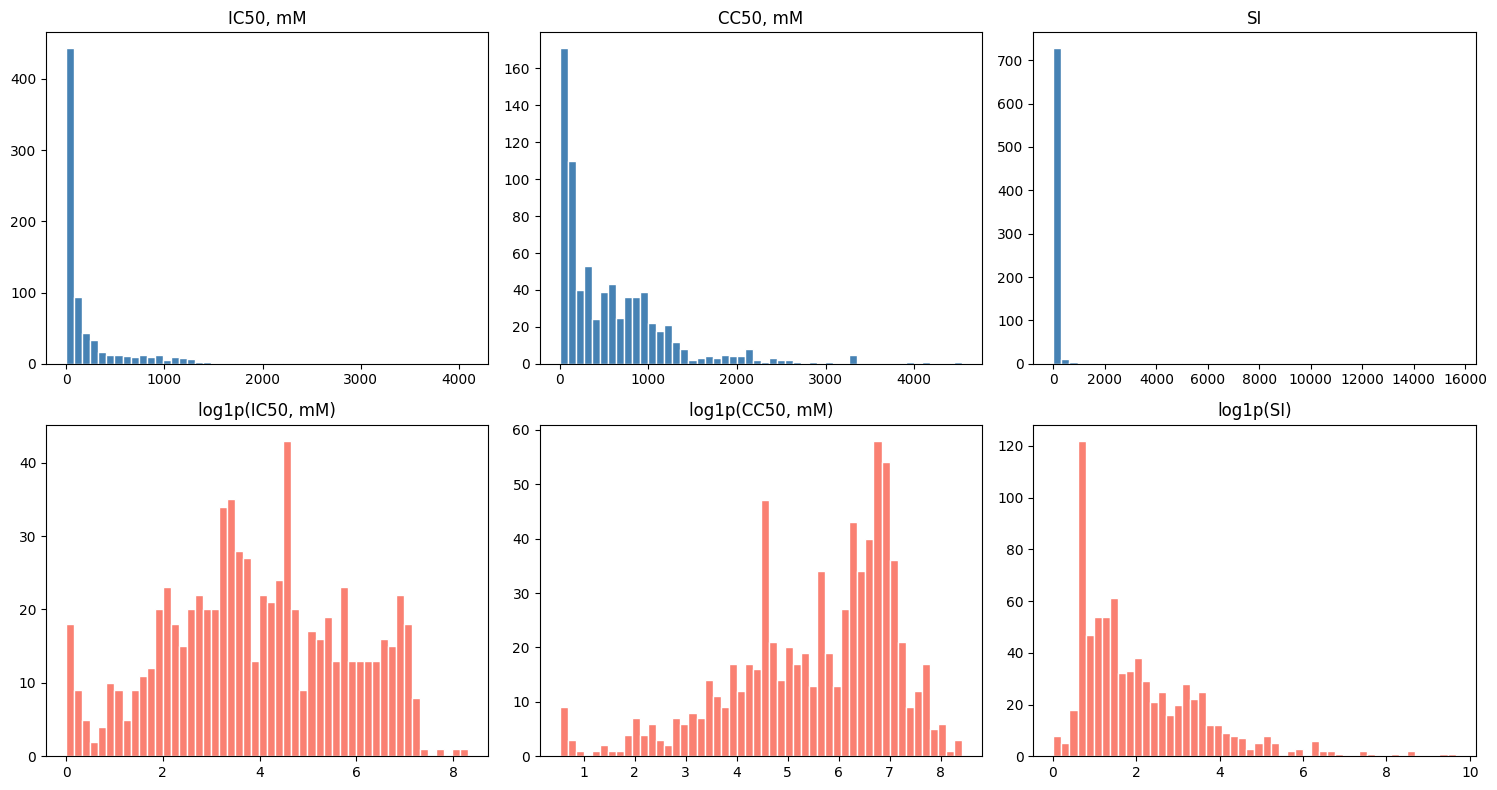

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, target in enumerate(TARGETS):
    vals     = train[target]
    log_vals = np.log1p(vals)

    axes[0, i].hist(vals, bins=50, color='steelblue', edgecolor='white')
    axes[0, i].set_title(target)

    axes[1, i].hist(log_vals, bins=50, color='salmon', edgecolor='white')
    axes[1, i].set_title(f'log1p({target})')

    print(f'{target}: skew={vals.skew():.2f}  ->  log skew={log_vals.skew():.2f}')

plt.tight_layout()
plt.show()

Все три таргета имеют выраженную правостороннюю асимметрию:
- IC50: skew 3.79 -> -0.06 после log
- CC50: skew 2.06 -> -0.90
- SI:   skew 15.63 -> 1.54

После log1p распределения становятся значительно более компактными.

Вывод: использовать log1p-преобразование таргетов при обучении, expm1 при получении предсказаний.

## Корреляции между таргетами

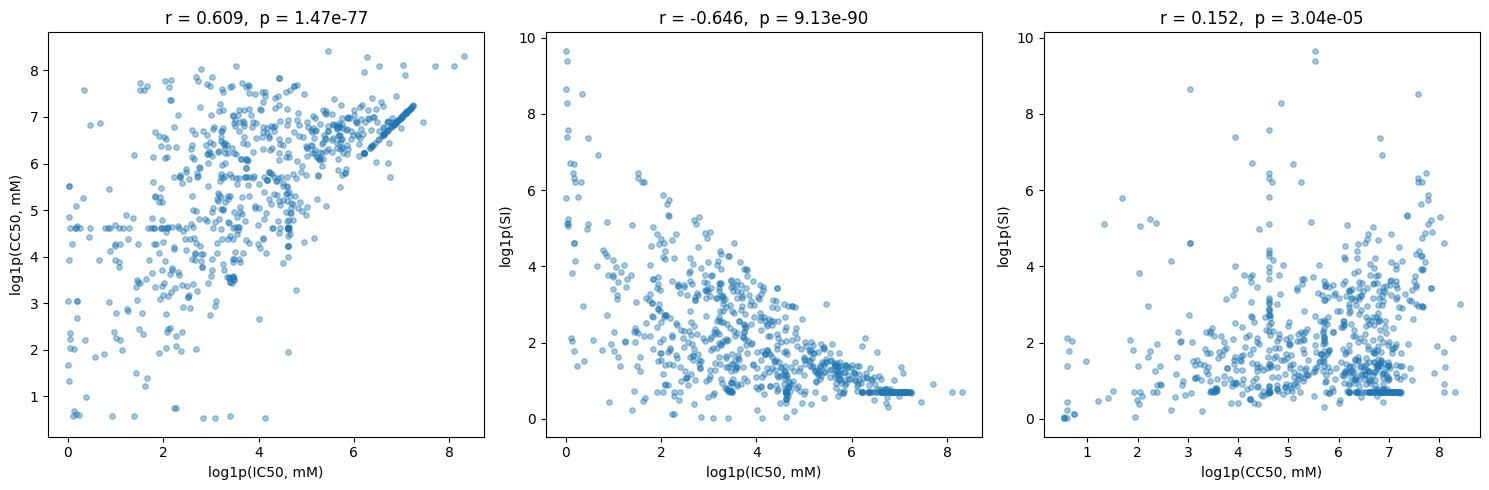

In [59]:
pairs = [('IC50, mM', 'CC50, mM'), ('IC50, mM', 'SI'), ('CC50, mM', 'SI')]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (x, y) in zip(axes, pairs):
    lx = np.log1p(train[x])
    ly = np.log1p(train[y])
    r, p = pearsonr(lx, ly)
    ax.scatter(lx, ly, alpha=0.4, s=15)
    ax.set_xlabel(f'log1p({x})')
    ax.set_ylabel(f'log1p({y})')
    ax.set_title(f'r = {r:.3f},  p = {p:.2e}')

plt.tight_layout()
plt.show()

# Анализ признаков

## Топ признаков по корреляции с таргетами

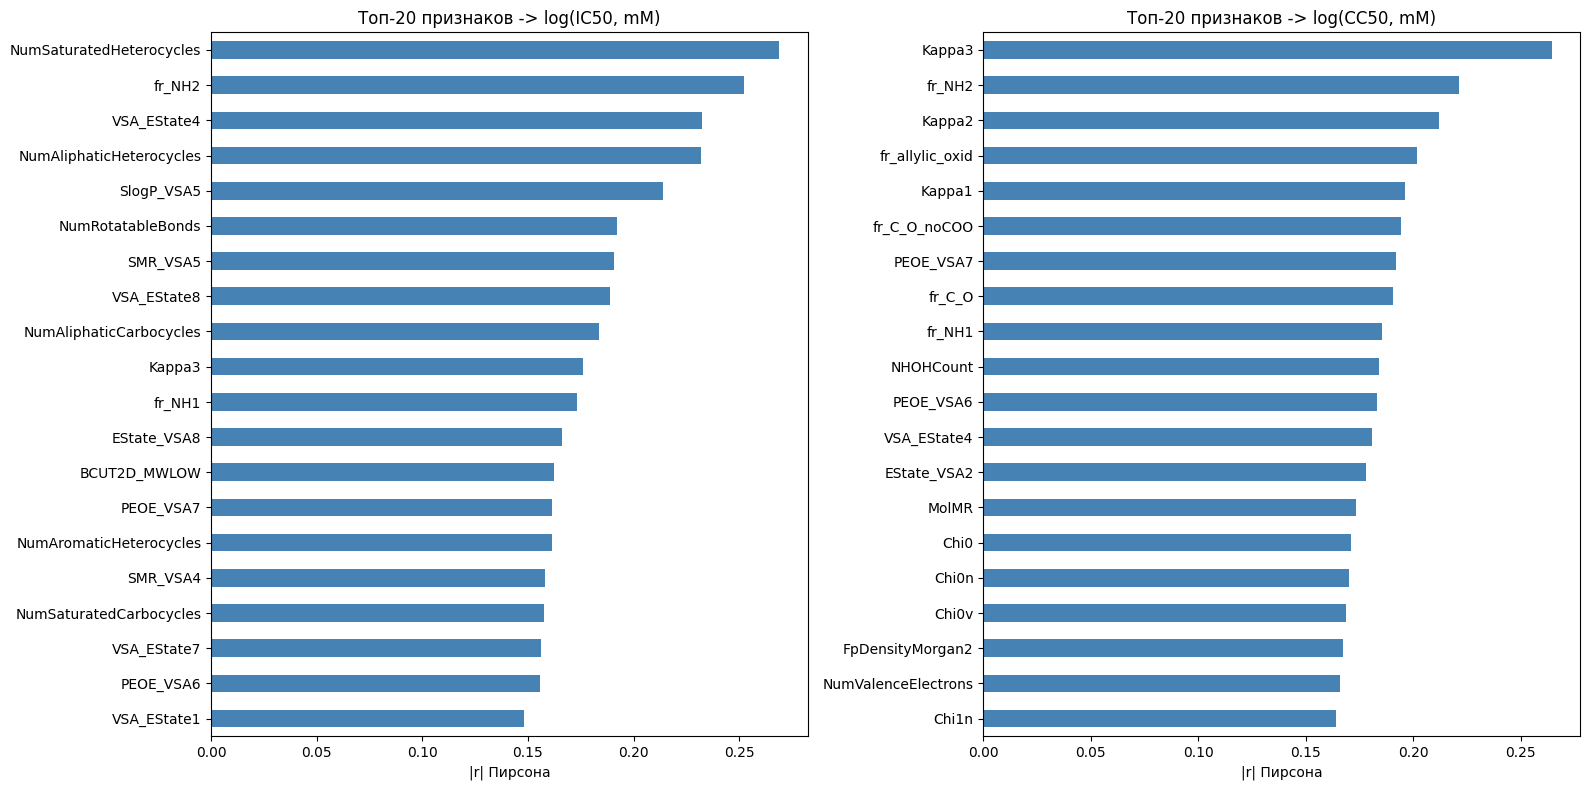

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for i, target in enumerate(['IC50, mM', 'CC50, mM']):
    log_target = np.log1p(train[target])
    corrs = train[features].corrwith(log_target).abs()
    top20 = corrs.sort_values(ascending=False).head(20)
    top20.sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Топ-20 признаков -> log({target})')
    axes[i].set_xlabel('|r| Пирсона')

plt.tight_layout()
plt.show()

## Коллинеарные признаки

In [61]:
corr_matrix = train[features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.95
]

print(f'Пар с корреляцией > 0.95: {len(high_corr_pairs)}')
pd.DataFrame(high_corr_pairs, columns=['признак_1', 'признак_2', 'корреляция']).sort_values('корреляция', ascending=False).head(15)

Пар с корреляцией > 0.95: 91


,признак_1,признак_2,корреляция
0,MaxEStateIndex,MaxAbsEStateIndex,1.000000
86,fr_benzene,NumAromaticCarbocycles,1.000000
83,fr_COO2,fr_COO,1.000000
87,fr_nitro_arom_nonortho,fr_nitro_arom,1.000000
85,fr_Nhpyrrole,fr_Ar_NH,1.000000
90,fr_phenol_noOrthoHbond,fr_phenol,1.000000
2,ExactMolWt,MolWt,0.999999
64,HeavyAtomCount,Chi1,0.998746
1,HeavyAtomMolWt,MolWt,0.996985
3,ExactMolWt,HeavyAtomMolWt,0.996955


Обнаружено значительное количество пар с высокой корреляцией.
При использовании CatBoost агрессивное удаление коллинеарных признаков необязательно — модель сама справляется с избыточностью.
Для других моделей (RF, XGB) можно удалить один из каждой пары.

# Аномальные объекты (Isolation Forest)

In [62]:
# Используем признаки без пропусков для Isolation Forest
feat_no_na = [c for c in features if train[c].isnull().sum() == 0 and c not in constant_combined]

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
anomaly_labels = iso.fit_predict(train[feat_no_na])

n_anomalies = (anomaly_labels == -1).sum()
print(f'Выявлено аномальных объектов (contamination=0.05): {n_anomalies}')
print()
print('Таргеты аномальных объектов:')
print(train[anomaly_labels == -1][TARGETS].describe())

Выявлено аномальных объектов (contamination=0.05): 38

Таргеты аномальных объектов:
         IC50, mM    CC50, mM          SI
count   38.000000   38.000000   38.000000
mean   118.791664  415.844969   16.082246
std    145.574691  235.261221   34.778061
min      0.179381    0.880264    0.645000
25%     27.685499  192.104277    2.466063
50%     59.588942  443.981115    4.005616
75%    150.869218  552.015772   10.889399
max    647.103436  875.661343  159.969025


Isolation Forest выявил аномальные объекты, однако большинство из них выглядят биологически правдоподобными.
Удаление таких наблюдений на данном этапе не выглядит оправданным.
Решение: оставить все объекты, использовать ансамблевые методы устойчивые к выбросам.

# Анализ сдвига train/test (Adversarial Validation)

In [63]:
# KS-тест по каждому признаку
feat_clean = [c for c in features if c not in constant_combined]

ks_results = []
for col in feat_clean:
    tr_vals = train[col].dropna()
    te_vals = test[col].dropna()
    stat, p = ks_2samp(tr_vals, te_vals)
    ks_results.append({'признак': col, 'ks_stat': stat, 'p_value': p})

ks_df = pd.DataFrame(ks_results).sort_values('ks_stat', ascending=False)
n_shifted = (ks_df['p_value'] < 0.05).sum()

print(f'Признаков со значимым сдвигом (p < 0.05): {n_shifted} из {len(feat_clean)}')
print()
print('Топ-10 сдвинутых признаков:')
print(ks_df.head(10).to_string(index=False))

Признаков со значимым сдвигом (p < 0.05): 7 из 192

Топ-10 сдвинутых признаков:
            признак  ks_stat  p_value
              Chi1n 0.116607 0.011005
NumValenceElectrons 0.108676 0.021537
              Chi1v 0.107212 0.024649
               Chi0 0.105944 0.027122
   FpDensityMorgan3 0.103004 0.034929
          LabuteASA 0.099393 0.044775
              Chi0n 0.098003 0.049955
     HeavyAtomMolWt 0.094136 0.065685
             Kappa2 0.092724 0.073019
              Chi0v 0.092671 0.073576


In [64]:
# Adversarial classifier: можем ли мы отличить train от test?
imputer = SimpleImputer(strategy='median')

X_adv = pd.concat([train[feat_clean], test[feat_clean]], axis=0)
y_adv = np.array([0] * len(train) + [1] * len(test))

X_adv_imp = imputer.fit_transform(X_adv)

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
roc_auc = cross_val_score(clf, X_adv_imp, y_adv, cv=5, scoring='roc_auc').mean()

print(f'Adversarial ROC-AUC: {roc_auc:.4f}')
print('(0.5 = нет сдвига, 1.0 = полное разделение)')

Adversarial ROC-AUC: 0.5278
(0.5 = нет сдвига, 1.0 = полное разделение)


Adversarial ROC-AUC = 0.527. Сдвиг между train и test практически отсутствует.
Выборки статистически неразличимы — domain shift не является проблемой.

# PCA и структура данных

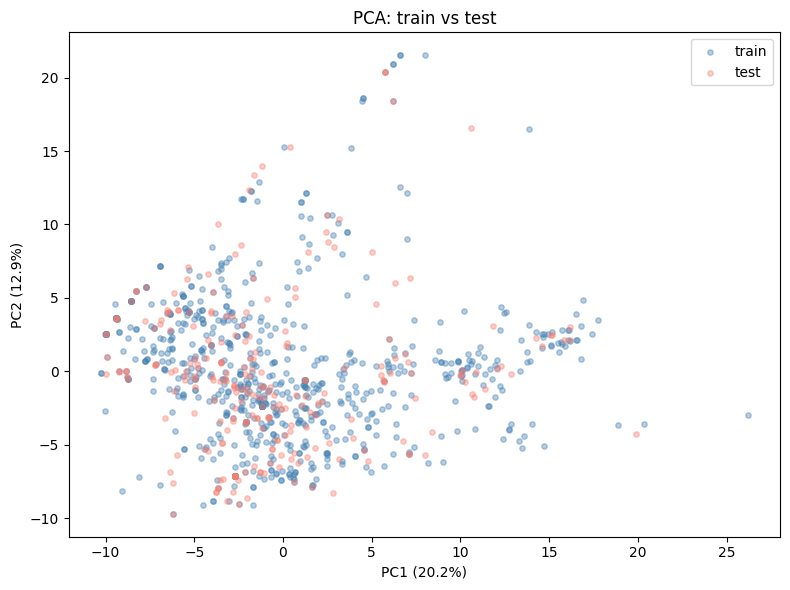

Объясненная дисперсия (PC1+PC2): 33.0%


In [66]:
scaler = StandardScaler()
imputer_pca = SimpleImputer(strategy='median')

X_all = pd.concat([train[feat_clean], test[feat_clean]], axis=0)
X_all_imp = imputer_pca.fit_transform(X_all)
X_all_scaled = scaler.fit_transform(X_all_imp)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:len(train), 0], X_pca[:len(train), 1],
            alpha=0.4, s=15, label='train', color='steelblue')
plt.scatter(X_pca[len(train):, 0], X_pca[len(train):, 1],
            alpha=0.4, s=15, label='test', color='salmon')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA: train vs test')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Объясненная дисперсия (PC1+PC2): {pca.explained_variance_ratio_[:2].sum()*100:.1f}%')

# Кластеризация

k=2: silhouette=0.2462
k=3: silhouette=0.1176
k=4: silhouette=0.1170
k=5: silhouette=0.1275
k=6: silhouette=0.1283
k=7: silhouette=0.1203


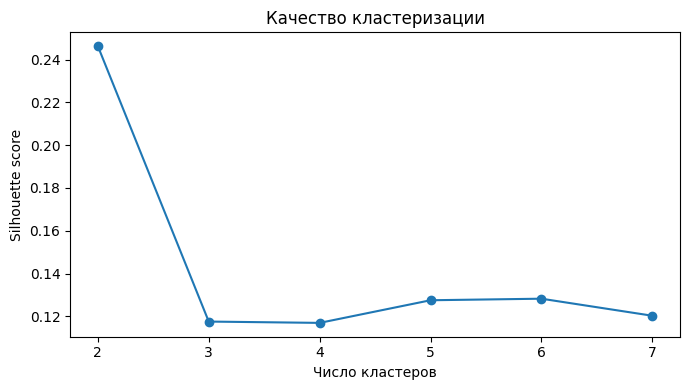

In [67]:
X_train_imp    = imputer_pca.transform(train[feat_clean])
X_train_scaled = scaler.transform(X_train_imp)

silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    score  = silhouette_score(X_train_scaled, labels)
    silhouette_scores.append(score)
    print(f'k={k}: silhouette={score:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), silhouette_scores, marker='o')
plt.xlabel('Число кластеров')
plt.ylabel('Silhouette score')
plt.title('Качество кластеризации')
plt.tight_layout()
plt.show()

Кластеризация не выявила четко разделенных групп объектов.
Низкие значения silhouette показывают, что химическое пространство имеет сложную структуру.
Это подтверждает необходимость использования гибких нелинейных моделей.

# Предобработка данных

In [68]:
# 1. Удаляем константные признаки
train_clean = train.drop(columns=constant_combined)
test_clean  = test.drop(columns=constant_combined)

features_clean = [c for c in train_clean.columns if c not in TARGETS]
print(f'Признаков после удаления констант: {len(features_clean)}')

# 2. Заполняем пропуски медианой по train
medians = train_clean[features_clean].median()
train_clean[features_clean] = train_clean[features_clean].fillna(medians)
test_clean = test_clean.fillna(medians)

print(f'Пропуски в train после заполнения: {train_clean.isnull().sum().sum()}')
print(f'Пропуски в test после заполнения:  {test_clean.isnull().sum().sum()}')

Признаков после удаления констант: 192
Пропуски в train после заполнения: 0
Пропуски в test после заполнения:  0


# Feature Engineering

In [69]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Отношения между химическими свойствами
    df['hetero_ratio']        = df['NumHeteroatoms']    / (df['HeavyAtomCount'] + 1)
    df['donor_acceptor_sum']  = df['NumHDonors']        + df['NumHAcceptors']
    df['donor_acceptor_ratio']= df['NumHDonors']        / (df['NumHAcceptors'] + 1)
    df['rotatable_per_heavy'] = df['NumRotatableBonds'] / (df['HeavyAtomCount'] + 1)
    df['rings_per_heavy']     = df['RingCount']         / (df['HeavyAtomCount'] + 1)
    df['aromatic_ratio']      = df['NumAromaticRings']  / (df['RingCount'] + 1)
    df['tpsa_per_heavy']      = df['TPSA']              / (df['HeavyAtomCount'] + 1)
    df['mol_logp_per_heavy']  = df['MolLogP']           / (df['HeavyAtomCount'] + 1)
    df['mol_mr_per_molwt']    = df['MolMR']             / (df['MolWt'] + 1)

    # Агрегаты по группам дескрипторов
    fr_cols     = [c for c in df.columns if c.startswith('fr_')]
    vsa_cols    = [c for c in df.columns if 'VSA' in c]
    estate_cols = [c for c in df.columns if 'EState' in c]

    df['fr_total']         = df[fr_cols].sum(axis=1)
    df['fr_nonzero_count'] = (df[fr_cols] > 0).sum(axis=1)
    df['vsa_total']        = df[vsa_cols].sum(axis=1)
    df['vsa_nonzero_count']= (df[vsa_cols] > 0).sum(axis=1)
    df['estate_abs_sum']   = df[estate_cols].abs().sum(axis=1)

    return df


train_fe = add_features(train_clean)
test_fe  = add_features(test_clean)

features_fe = [c for c in train_fe.columns if c not in TARGETS]

print(f'Признаков до feature engineering:  {len(features_clean)}')
print(f'Признаков после feature engineering: {len(features_fe)}')

new_cols = [c for c in features_fe if c not in features_clean]
print(f'Новых признаков: {len(new_cols)}')
train_fe[new_cols].head()

Признаков до feature engineering:  192
Признаков после feature engineering: 206
Новых признаков: 14


,hetero_ratio,donor_acceptor_sum,donor_acceptor_ratio,rotatable_per_heavy,rings_per_heavy,aromatic_ratio,tpsa_per_heavy,mol_logp_per_heavy,mol_mr_per_molwt,fr_total,fr_nonzero_count,vsa_total,vsa_nonzero_count,estate_abs_sum
index,,,,,,,,,,,,,,
0,0.214286,3,0.000,0.071429,0.142857,0.333333,0.890714,0.155100,0.290722,6,6,354.540880,29,119.756907
1,0.291667,7,0.600,0.166667,0.083333,0.333333,3.850833,0.124025,0.257140,8,8,630.046320,38,235.698958
2,0.125000,4,0.250,0.291667,0.166667,0.200000,1.270417,0.159513,0.297664,8,6,601.067594,35,194.732425
3,0.419355,8,0.125,0.161290,0.096774,0.750000,4.215484,0.155568,0.225735,22,13,764.380303,36,314.052555
4,0.083333,2,0.500,0.000000,0.333333,0.000000,2.168333,0.159492,0.296154,1,1,288.454962,16,99.043602


# Финальные матрицы для обучения

In [70]:
X_train = train_fe[features_fe].copy()
X_test  = test_fe[features_fe].copy()

y_ic50 = np.log1p(train_fe['IC50, mM'])
y_cc50 = np.log1p(train_fe['CC50, mM'])

# GroupKFold по дубликатам признаков
train_fe['group'] = train_fe[features_clean].apply(tuple, axis=1).rank(method='dense').astype(int)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Уникальных групп (для GroupKFold): {train_fe["group"].nunique()}')
print(f'y_ic50 mean={y_ic50.mean():.3f}, std={y_ic50.std():.3f}')
print(f'y_cc50 mean={y_cc50.mean():.3f}, std={y_cc50.std():.3f}')

X_train: (751, 206)
X_test:  (250, 206)
Уникальных групп (для GroupKFold): 630
y_ic50 mean=3.937, std=1.834
y_cc50 mean=5.545, std=1.581


# Итоги EDA

Структура данных:
- 751 объект в train, 250 в test, 210 молекулярных дескрипторов
- пропуски только в 12 признаках (PartialCharge, BCUT2D), заполняем медианой
- нет строковых признаков, все дескрипторы числовые

Целевые переменные:
- все три таргета имеют сильную правостороннюю асимметрию, log1p обязателен
- SI = CC50 / IC50 абсолютно точно, предсказываем только IC50 и CC50, SI вычисляем

Признаки:
- 18 константных признаков удалены
- обнаружено много высококоррелирующих пар, для CatBoost не удаляем
- добавлены 14 новых химически осмысленных признаков через feature engineering

Качество данных:
- обнаружены дубликаты по признакам с разными таргетами: шум измерений
- это создает естественный потолок качества модели
- использовать GroupKFold при валидации

Аномалии и сдвиг:
- Isolation Forest выявил аномальные объекты, удалять не рекомендуется
- adversarial validation показал умеренный сдвиг train/test, критического нет

План моделирования:
1. обучение на log1p таргетах, предсказания через expm1
2. SI = pred_CC50 / pred_IC50
3. GroupKFold по дубликатам
4. CatBoost, LightGBM, RandomForest
5. ансамблирование лучших моделей
6. анализ важности признаков        